# 03 — Embeddings

Computes frozen ESM2 embeddings for *E. coli* K-12 proteins and for the
tryptic peptides produced by `plm_benchmark.digest` (Notebook 02).

Scope for now: enzymatic digestion only — `plm_benchmark.fragments`
(sliding-window / terminal truncation) is intentionally excluded and
will get its own pass once the digestion embeddings look right.

Kernel: **Python (plm-benchmark)** (the repo `.venv`). Needs
`requirements-ml.txt` (torch + transformers) installed.

In [1]:
import sys
from pathlib import Path

# notebooks/ lives one level below the repo root
REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC = REPO_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

print("repo root:", REPO_ROOT)

repo root: /Users/annaquaglieri/Projects/ProteinPrediction


## Load the proteome

Reuses the FASTA fetched in `01_fetch_proteome.ipynb`; re-run that
notebook first if `data/raw/<proteome_id>.fasta` isn't there yet.

In [2]:
import yaml

from plm_benchmark.data_io import load_fasta

config = yaml.safe_load((REPO_ROOT / "configs" / "organism_ecoli_k12.yaml").read_text())
proteome_id = config["uniprot_proteome_id"]
fasta_path = REPO_ROOT / "data" / "raw" / f"{proteome_id}.fasta"

sequences = load_fasta(fasta_path)
print(f"{len(sequences):,} sequences loaded from {fasta_path.name}")

4,403 sequences loaded from UP000000625.fasta


## Digest a subset of proteins

Embedding the full ~4,300-protein proteome and all of its tryptic
peptides is expensive to iterate on, so this notebook works on a small
random subset. Bump `N_PROTEINS` (or drop the subsampling entirely)
once the pipeline below looks right.

Digestion parameters come from `configs/enzymes.yaml`, same as
Notebook 02.

In [3]:
import random

from plm_benchmark.digest import digest

digest_config = yaml.safe_load((REPO_ROOT / "configs" / "enzymes.yaml").read_text())

N_PROTEINS = 20
rng = random.Random(0)
protein_ids = rng.sample(list(sequences), N_PROTEINS)
proteins = {pid: sequences[pid] for pid in protein_ids}

print(f"digesting {len(proteins)} proteins with {digest_config['default_enzyme']!r}")

digesting 20 proteins with 'trypsin'


In [4]:
digest_config

{'default_enzyme': 'trypsin',
 'missed_cleavages': [0, 1, 2],
 'min_length': 6,
 'max_length': 40,
 'enzymes_to_compare': ['trypsin',
  'lysc',
  'glutamyl endopeptidase',
  'chymotrypsin high specificity',
  'proteinase k']}

In [6]:
peptide_rows = []
for protein_id, seq in proteins.items():
    peptides = digest(
        seq,
        enzyme=digest_config["default_enzyme"],
        missed_cleavages=max(digest_config["missed_cleavages"]),
        min_length=digest_config["min_length"],
        max_length=digest_config["max_length"],
    )
    for pep in peptides:
        peptide_rows.append(
            {
                "protein_id": protein_id,
                "peptide": pep.sequence,
                "start": pep.start,
                "end": pep.end,
                "missed_cleavages": pep.missed_cleavages,
                "protein_sequence": seq,
                "coverage": len(pep) / len(seq),
            }
        )

import pandas as pd

peptide_df = pd.DataFrame(peptide_rows)
print(f"{len(peptide_df):,} peptides from {len(proteins)} proteins")
peptide_df.head()

1,121 peptides from 20 proteins


,protein_id,peptide,start,end,missed_cleavages,protein_sequence,coverage
0,sp|P0AD86|LPT_ECOLI,MKRISTTITTTITITTGNGAG,0,21,2,MKRISTTITTTITITTGNGAG,1.000000
1,sp|P0AD86|LPT_ECOLI,RISTTITTTITITTGNGAG,2,21,1,MKRISTTITTTITITTGNGAG,0.904762
2,sp|P0AD86|LPT_ECOLI,ISTTITTTITITTGNGAG,3,21,0,MKRISTTITTTITITTGNGAG,0.857143
3,sp|P37750|WBBJ_ECOLI,MILKLAK,0,7,1,MILKLAKRYGLCGFIRLVRDVLLTRVFYRNCRIIRFPCYIRNDGSI...,0.035714
4,sp|P37750|WBBJ_ECOLI,MILKLAKR,0,8,2,MILKLAKRYGLCGFIRLVRDVLLTRVFYRNCRIIRFPCYIRNDGSI...,0.040816


In [12]:
peptide_df[peptide_df['protein_id'] == "sp|P37750|WBBJ_ECOLI"].sort_values(["missed_cleavages","start"]).head()

,protein_id,peptide,start,end,missed_cleavages,protein_sequence,coverage
8,sp|P37750|WBBJ_ECOLI,YGLCGFIR,8,16,0,MILKLAKRYGLCGFIRLVRDVLLTRVFYRNCRIIRFPCYIRNDGSI...,0.040816
13,sp|P37750|WBBJ_ECOLI,DVLLTR,19,25,0,MILKLAKRYGLCGFIRLVRDVLLTRVFYRNCRIIRFPCYIRNDGSI...,0.030612
22,sp|P37750|WBBJ_ECOLI,FPCYIR,35,41,0,MILKLAKRYGLCGFIRLVRDVLLTRVFYRNCRIIRFPCYIRNDGSI...,0.030612
25,sp|P37750|WBBJ_ECOLI,NDGSINFGENFTSGVGLR,41,59,0,MILKLAKRYGLCGFIRLVRDVLLTRVFYRNCRIIRFPCYIRNDGSI...,0.091837
27,sp|P37750|WBBJ_ECOLI,LDAFGR,59,65,0,MILKLAKRYGLCGFIRLVRDVLLTRVFYRNCRIIRFPCYIRNDGSI...,0.030612


## Compute embeddings

`plm_benchmark.embed.embed_sequences` lazy-imports torch/transformers
and mean-pools the last hidden state (masking out padding) into one
fixed-length vector per sequence. Uses the default small ESM2
checkpoint (`facebook/esm2_t12_35M_UR50D`); the first call downloads
and caches the model weights.

In [16]:
from plm_benchmark.embed import DEFAULT_MODEL, embed_sequences, _load_model

print("model:", DEFAULT_MODEL)

tokenizer, model, torch = _load_model(DEFAULT_MODEL)

model: facebook/esm2_t12_35M_UR50D


### Full-length protein embeddings

In [24]:
full_ids = list(proteins)
full_seqs = [proteins[pid] for pid in full_ids]

X_full = embed_sequences(full_seqs, model_name=DEFAULT_MODEL, pooling="mean")
print("X_full shape:", X_full.shape)

X_full shape: (20, 480)


In [25]:
X_full

array([[ 0.10022116, -0.0062105 ,  0.04057384, ..., -0.44713426,
        -0.14378749,  0.02064664],
       [ 0.11867458,  0.04925522, -0.04244349, ..., -0.12847044,
        -0.13396503,  0.1118433 ],
       [ 0.02030913,  0.05321259,  0.02574161, ..., -0.03365602,
        -0.06679923, -0.06015027],
       ...,
       [-0.00922095, -0.03377175, -0.02991544, ..., -0.05598285,
         0.05672707, -0.0210984 ],
       [-0.02978732, -0.02862659,  0.0650158 , ...,  0.02586423,
         0.03046399, -0.00957501],
       [ 0.17820953,  0.0492668 ,  0.07225969, ..., -0.05184009,
        -0.01276687,  0.06088771]], shape=(20, 480), dtype=float32)

### Peptide embeddings

In [26]:
X_pep = embed_sequences(
    peptide_df["peptide"].tolist(), model_name=DEFAULT_MODEL, pooling="mean"
)
print("X_pep shape:", X_pep.shape)

X_pep shape: (1121, 480)


## Sanity check

Cosine similarity between each peptide's embedding and its own parent
protein's full-length embedding, vs. sequence coverage. Higher-coverage
peptides (more missed cleavages, closer to full length) should tend to
look more similar to the full protein.

In [27]:
import numpy as np

full_by_id = {pid: X_full[i] for i, pid in enumerate(full_ids)}


def cosine_sim(a, b):
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)))


peptide_df["sim_to_parent"] = [
    cosine_sim(X_pep[i], full_by_id[row.protein_id])
    for i, row in enumerate(peptide_df.itertuples())
]

peptide_df[["coverage", "sim_to_parent"]].corr()

,coverage,sim_to_parent
coverage,1.000000,0.339822
sim_to_parent,0.339822,1.000000


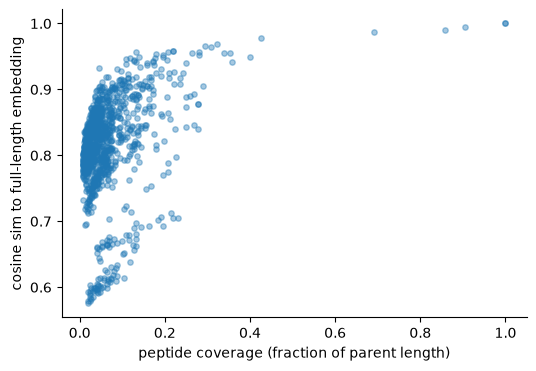

In [28]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(peptide_df["coverage"], peptide_df["sim_to_parent"], alpha=0.4, s=15)
ax.set_xlabel("peptide coverage (fraction of parent length)")
ax.set_ylabel("cosine sim to full-length embedding")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

## Save embeddings

Written to `data/processed/` (not committed — see `.gitignore`).

In [29]:
processed_dir = REPO_ROOT / "data" / "processed"
processed_dir.mkdir(parents=True, exist_ok=True)

np.save(processed_dir / "full_protein_embeddings.npy", X_full)
np.save(processed_dir / "peptide_embeddings.npy", X_pep)
pd.Series(full_ids).to_csv(processed_dir / "full_protein_ids.csv", index=False, header=["protein_id"])
peptide_df.to_csv(processed_dir / "peptide_digest.csv", index=False)

print("saved to", processed_dir)

saved to /Users/annaquaglieri/Projects/ProteinPrediction/data/processed


## Next

- Scale `N_PROTEINS` up (or remove the subsampling) once this looks right.
- `plm_benchmark.probe` trains/evaluates a probe on top of `X_full` given
  labels (still TODO — see the Phase 1 checklist in README.md).
- `plm_benchmark.fragments` (sliding-window / terminal truncation)
  embeddings are deliberately out of scope here; add a follow-up
  notebook once digestion-based results look right.